# Inverse beamforming: recovering channel data with `zea.inverse`

Delay-and-sum (DAS) beamforming maps **pre-beamformed channel data** to a **post-beamformed
image**. This notebook runs that map *backwards*: given only a beamformed image, we recover the
channel data that produced it, using the [`zea.inverse`](../../_autosummary/zea.inverse.rst)
subpackage.

Because the DAS operator sums on the order of `n_el * n_tx` samples into every pixel, this
inversion is severely underdetermined. We compare the two provided strategies:

1. **Direct (pseudo-inverse)** — solve for the full channel-data cube with CGLS. This
   reproduces the image essentially perfectly, yet recovers the *physical* channel data poorly:
   CGLS from zero converges to the minimum-norm solution, which is generally not the true data.
2. **Scatterer prior** — parameterize the medium as point scatterers (positions seeded from the
   image, magnitudes solved by CGLS). The physical parameterization regularizes the nullspace
   and recovers channel data far better on point-target scans.

The scatterer-prior inversion follows the off-grid scatterer model of
[van de Schaft et al., *Off-Grid Ultrasound Imaging by Stochastic Optimization*](https://arxiv.org/abs/2407.02285).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tue-bmd/zea/blob/main/docs/source/notebooks/pipeline/inverse_beamforming_example.ipynb)
[![View on GitHub](https://img.shields.io/badge/GitHub-View%20Source-blue?logo=github)](https://github.com/tue-bmd/zea/blob/main/docs/source/notebooks/pipeline/inverse_beamforming_example.ipynb)

‼️ **Important:** This notebook is optimized for **GPU/TPU**. Code execution on a **CPU** may be very slow.

If you are running in Colab, please enable a hardware accelerator via:

**Runtime → Change runtime type → Hardware accelerator → GPU/TPU** 🚀.

In [1]:
%%capture
%pip install zea

In [2]:
import os

os.environ["KERAS_BACKEND"] = "jax"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 80
import numpy as np
from keras import ops
from scipy.signal import hilbert

import zea
from zea import Parameters, Probe
from zea.beamform.delays import compute_t0_delays_planewave
from zea.beamform.phantoms import fish
from zea.inverse import DASOperator, ScattererSimulator, invert_direct, invert_scatterers

zea.init_device()

zea: Using backend 'jax'


-------------------GPU settings-------------------
7/8 GPUs were disabled
     memory
GPU        
0       81072
Selecting 1 GPU based on available memory.
Selected GPU 0 with Free Memory: 81072.00 MiB
--------------------------------------------------


'gpu:0'

In [3]:
# Parameters (overridden for fast CI runs, see tests/test_notebooks.py)
n_plane_waves = 5
n_speckle = 15000  # diffuse background scatterers
n_scatterers = 15000  # scatterers fitted by the inversion
n_iter_direct = 30
n_iter_scatterers = 60

## A realistic synthetic scan

We mimic a real acquisition as closely as the simulator allows: the Verasonics L11-5v
probe preset from [`zea.probes`](../../_autosummary/zea.probes.rst) (128 elements, 0.3 mm
pitch, 6.25 MHz center frequency), 4× sampling, and `n_plane_waves` steered plane waves.
The two-way waveform is a 1.5-cycle excitation convolved twice (transmit + receive) with a
Gaussian impulse response matching the probe's fractional bandwidth — the shape a scanner
actually records. The medium combines the `fish` point phantom from
[`zea.beamform.phantoms`](../../_autosummary/zea.beamform.phantoms.rst) with diffuse
speckle scatterers, and the channel data receives white receiver noise at ~30 dB SNR.
Since we simulate the channel data ourselves, we know exactly what the inversion should
recover.

In [4]:
probe = Probe.from_name("verasonics_l11_5v")
probe_geometry = np.asarray(probe.probe_geometry, dtype="float32")
n_el = probe_geometry.shape[0]
center_frequency = float(probe.probe_center_frequency)  # 6.25 MHz
sampling_frequency = 4 * center_frequency  # standard 4x sampling
sound_speed = 1540.0
pitch = float(probe_geometry[1, 0] - probe_geometry[0, 0])
n_ax = 1216
rng = np.random.default_rng(42)

polar_angles = np.deg2rad(np.linspace(-9.0, 9.0, n_plane_waves)).astype("float32")

# Two-way waveform: a 1.5-cycle excitation convolved twice (transmit + receive)
# with a Gaussian impulse response matching the probe's fractional bandwidth.
waveform_sampling_frequency = 250e6
t_exc = np.arange(int(1.5 / center_frequency * waveform_sampling_frequency))
t_exc = t_exc / waveform_sampling_frequency
excitation = np.sin(2 * np.pi * center_frequency * t_exc) * np.hanning(t_exc.size)
bandwidth = probe.probe_bandwidth_percent / 100 * center_frequency
sigma_t = np.sqrt(2 * np.log(2)) / (np.pi * bandwidth)
t_ir = np.arange(-3 * sigma_t, 3 * sigma_t, 1 / waveform_sampling_frequency)
impulse_response = np.exp(-(t_ir**2) / (2 * sigma_t**2)) * np.cos(
    2 * np.pi * center_frequency * t_ir
)
waveform = np.convolve(np.convolve(excitation, impulse_response), impulse_response)
waveform = (waveform / np.abs(waveform).max()).astype("float32")

# Ground truth: the fish phantom over diffuse tissue speckle
xlims, zlims = (-19e-3, 19e-3), (8e-3, 36e-3)
fish_positions = fish().astype("float32")
speckle_positions = np.stack(
    [
        rng.uniform(xlims[0], xlims[1], n_speckle),
        np.zeros(n_speckle),
        rng.uniform(zlims[0], zlims[1], n_speckle),
    ],
    axis=1,
).astype("float32")
scatterer_positions = np.concatenate([fish_positions, speckle_positions], axis=0)
scatterer_magnitudes = np.concatenate(
    [
        np.ones(len(fish_positions), dtype="float32"),
        (0.06 * rng.standard_normal(n_speckle)).astype("float32"),
    ]
)

parameters = Parameters(
    probe_geometry=probe_geometry,
    t0_delays=compute_t0_delays_planewave(
        probe_geometry, polar_angles, sound_speed=sound_speed
    ).astype("float32"),
    tx_apodizations=np.ones((n_plane_waves, n_el), dtype="float32"),
    initial_times=np.zeros(n_plane_waves, dtype="float32"),
    sampling_frequency=sampling_frequency,
    center_frequency=center_frequency,
    sound_speed=sound_speed,
    n_ax=n_ax,
    n_el=n_el,
    n_tx=n_plane_waves,
    n_ch=1,
    n_frames=1,
    focus_distances=np.full(n_plane_waves, np.inf, dtype="float32"),
    polar_angles=polar_angles,
    azimuth_angles=np.zeros(n_plane_waves, dtype="float32"),
    transmit_origins=np.zeros((n_plane_waves, 3), dtype="float32"),
    waveforms_two_way=np.tile(waveform, (n_plane_waves, 1)),
    element_width=pitch * 0.9,
    xlims=xlims,
    zlims=zlims,
    pixels_per_wavelength=2,
    f_number=1.0,
)

simulator = ScattererSimulator(parameters, chunk_size=4096)
channel_data_true = simulator(scatterer_magnitudes, positions=scatterer_positions)

# Receiver noise at ~30 dB channel SNR
channel_data_true = ops.convert_to_numpy(channel_data_true)
noise = (channel_data_true.std() / 10 ** (30 / 20)) * rng.standard_normal(channel_data_true.shape)
channel_data_true = (channel_data_true + noise).astype("float32")
print("ground-truth channel data:", channel_data_true.shape, "(n_tx, n_ax, n_el)")

ground-truth channel data: (5, 1216, 128) (n_tx, n_ax, n_el)


## The DAS beamformer as a linear operator

[`DASOperator`](../../_autosummary/zea.inverse.rst) wraps the standard `zea` beamforming
pipeline — [`TOFCorrection`](../../_autosummary/zea.ops.rst) followed by
[`DelayAndSum`](../../_autosummary/zea.ops.rst), chunked over grid pixels with
[`PatchedGrid`](../../_autosummary/zea.ops.rst) to bound memory — into a linear map
`channel data -> image`. Since it is built from differentiable Keras ops, its adjoint comes
for free via automatic differentiation — which is all we need for matrix-free least-squares
inversion. We beamform the ground-truth channel data to get the *measured image* that will
be the only input to the inversions below.

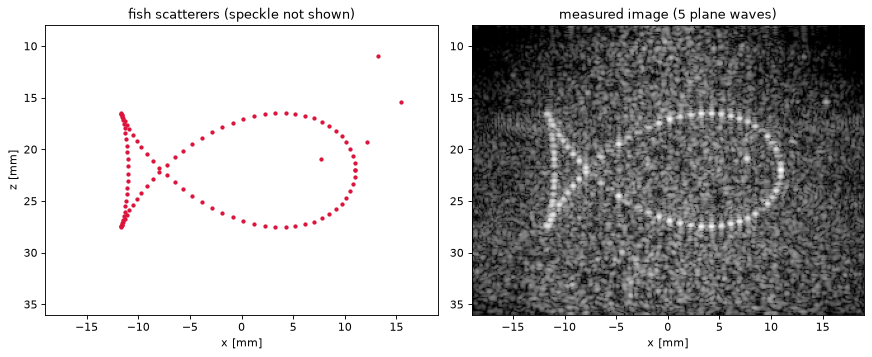

In [5]:
operator = DASOperator(parameters)
image_measured = operator.forward(channel_data_true)


def to_bmode(flat_image, dynamic_range=50):
    """Envelope-detect (along depth) and log-compress a flat RF image for display."""
    rf = ops.convert_to_numpy(operator.to_grid(flat_image))
    envelope = np.abs(hilbert(rf, axis=0))
    return np.clip(20 * np.log10(envelope / envelope.max() + 1e-9), -dynamic_range, 0)


extent = [xlims[0] * 1e3, xlims[1] * 1e3, zlims[1] * 1e3, zlims[0] * 1e3]  # mm
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(fish_positions[:, 0] * 1e3, fish_positions[:, 2] * 1e3, s=8, c="crimson")
axes[0].set(
    xlim=extent[:2],
    ylim=extent[2:],
    title="fish scatterers (speckle not shown)",
    xlabel="x [mm]",
    ylabel="z [mm]",
)
axes[0].set_aspect("equal")
axes[1].imshow(
    to_bmode(image_measured), cmap="gray", vmin=-50, vmax=0, extent=extent, aspect="equal"
)
axes[1].set(title=f"measured image ({n_plane_waves} plane waves)", xlabel="x [mm]")
plt.tight_layout()
plt.show()

The measured image looks like a routine clinical B-mode: speckle from the diffuse
scatterers, the fish outline standing ~25 dB above it, and a receiver-noise floor. This
image is the *only* input the inversions below see — recovering the channel data behind a
speckle-and-noise image is considerably harder than in a sterile point-target scene.

## Direct inversion: the pseudo-inverse

[`invert_direct`](../../_autosummary/zea.inverse.rst) treats every sample of the channel-data
cube as a free variable and minimizes `||beamform(channel_data) - image||^2` with CGLS. Started
from zero, CGLS converges to the **minimum-norm** least-squares solution — the Moore–Penrose
pseudo-inverse applied to the image.

In [6]:
result_direct = invert_direct(operator, image_measured, n_iter=n_iter_direct, verbose=True)


def correlation(a, b):
    """Absolute normalized correlation between two arrays."""
    a = np.asarray(ops.convert_to_numpy(a)).ravel()
    b = np.asarray(ops.convert_to_numpy(b)).ravel()
    a, b = a - a.mean(), b - b.mean()
    return abs(np.vdot(a, b)) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-30)


print(
    "pre-BF (channel data) correlation: "
    f"{correlation(result_direct.channel_data, channel_data_true):.3f}"
)
print(f"post-BF (image) correlation:       {correlation(result_direct.image, image_measured):.3f}")

zea: cgls iteration   3 | relative residual 5.6789e-01


zea: cgls iteration   6 | relative residual 3.4104e-01


zea: cgls iteration   9 | relative residual 2.0919e-01


zea: cgls iteration  12 | relative residual 1.4435e-01


zea: cgls iteration  15 | relative residual 1.0129e-01


...

zea: cgls iteration  21 | relative residual 6.2431e-02


zea: cgls iteration  24 | relative residual 5.1219e-02


zea: cgls iteration  27 | relative residual 4.4252e-02


zea: cgls iteration  30 | relative residual 3.8703e-02


pre-BF (channel data) correlation: 0.560
post-BF (image) correlation:       0.999


The image fit is essentially perfect while the channel-data correlation is poor — the
minimum-norm solution concentrates energy where the beamformer *samples*, not where the physical
echoes are. This is the nullspace problem in action.

## Scatterer-prior inversion

[`invert_scatterers`](../../_autosummary/zea.inverse.rst) instead represents the medium as point
scatterers: positions are seeded from the image envelope
([`seed_scatterers`](../../_autosummary/zea.inverse.rst)), and their magnitudes are solved with
CGLS through the composition `beamform(simulate(positions, magnitudes))` — still a linear
problem, but now constrained to physically consistent echoes.

In [7]:
result_scat = invert_scatterers(
    operator,
    image_measured,
    n_scatterers=n_scatterers,
    n_iter=n_iter_scatterers,
    seed=0,
    verbose=True,
)
print(
    "pre-BF (channel data) correlation: "
    f"{correlation(result_scat.channel_data, channel_data_true):.3f}"
)
print(f"post-BF (image) correlation:       {correlation(result_scat.image, image_measured):.3f}")

zea: cgls iteration   7 | relative residual 5.3080e-01


zea: cgls iteration  14 | relative residual 4.5333e-01


zea: cgls iteration  21 | relative residual 4.2260e-01


zea: cgls iteration  28 | relative residual 4.0717e-01


zea: cgls iteration  35 | relative residual 3.9766e-01


zea: cgls iteration  42 | relative residual 3.9182e-01


zea: cgls iteration  49 | relative residual 3.8747e-01


zea: cgls iteration  56 | relative residual 3.8433e-01


zea: cgls iteration  60 | relative residual 3.8252e-01


pre-BF (channel data) correlation: 0.659
post-BF (image) correlation:       0.924


## Comparing the recovered channel data

The channel data is the quantity that is never directly observed — below we compare it (for the
center transmit) between ground truth and the two inversions, together with the re-beamformed
images.

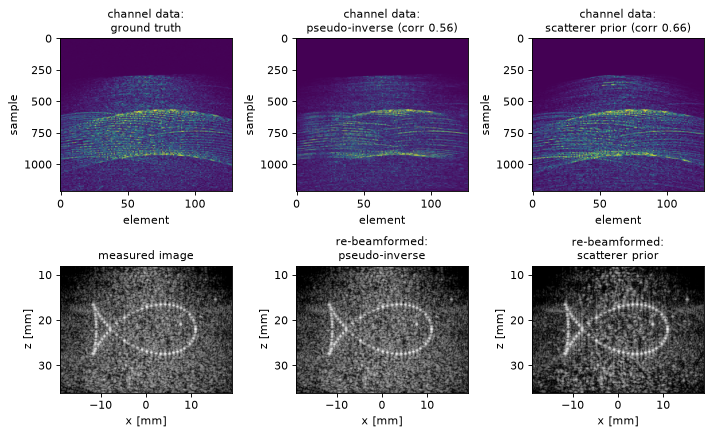

In [8]:
tx = 1  # center (zero-angle) transmit
panels = [
    (channel_data_true, "ground truth"),
    (result_direct.channel_data, "pseudo-inverse"),
    (result_scat.channel_data, "scatterer prior"),
]

fig, axes = plt.subplots(2, 3, figsize=(9, 5.5))
for ax, (cube, title) in zip(axes[0], panels):
    cube = np.asarray(ops.convert_to_numpy(cube))
    label = "" if title == "ground truth" else f" (corr {correlation(cube, channel_data_true):.2f})"
    ax.imshow(
        np.abs(cube[tx]), aspect="auto", cmap="viridis", vmax=np.percentile(np.abs(cube[tx]), 99.5)
    )
    ax.set_title(f"channel data:\n{title}{label}", fontsize=10)
    ax.set(xlabel="element", ylabel="sample")

images = [(image_measured, "measured image")] + [
    (result.image, f"re-beamformed:\n{title}")
    for result, (_, title) in zip([result_direct, result_scat], panels[1:])
]
for ax, (flat, title) in zip(axes[1], images):
    ax.imshow(to_bmode(flat), cmap="gray", vmin=-50, vmax=0, extent=extent, aspect="equal")
    ax.set_title(title, fontsize=10)
    ax.set(xlabel="x [mm]", ylabel="z [mm]")
plt.tight_layout()
plt.show()

## Takeaways

- The acquisition is realistic — an L11-5v probe, bandwidth-shaped two-way pulse,
  tissue speckle and receiver noise — and both inversions still **fit the image** well — the post-beamformed image barely
  constrains which channel data produced it.
- The **scatterer prior** recovers more of the physical channel data (the hyperbolic echo
  signatures in the top row): its parameterization regularizes the ~`n_el * n_tx`-fold
  nullspace of the DAS operator.
- The bright fish points are recovered well; the diffuse **speckle** floor is much harder —
  a real physical limitation, and the same gap the real-scans notebook shows between the
  CIRS point phantom and in-vivo carotid tissue.
- Everything here is backend-agnostic Keras: the same code runs on JAX, TensorFlow and PyTorch.
  See the [`zea.inverse` API reference](../../_autosummary/zea.inverse.rst) for the full
  documentation, including joint position refinement (`refine_iters`) with
  [`zea.backend.optimizer.adam`](../../_autosummary/zea.backend.optimizer.rst).
